# Lecture 03: Lagrangian Submanifolds

**Source span.** Printed pages 13-19; physical PDF pages 27-33 in `Lectures on Symplectic Geometry.pdf` according to the course source map. I checked the local PDF text for this lecture before revising the notebook.

**Lecture goal.** Learn to recognize Lagrangian submanifolds in cotangent bundles and products. The main lesson is that the Lagrangian condition often turns a geometric statement into a differential identity: graphs of one-forms are Lagrangian exactly when the one-form is closed, conormal bundles are Lagrangian because the tautological form vanishes on them, and graphs of symplectomorphisms are Lagrangian for the twisted product form.

The lecture begins with submanifold language because all later tests happen on tangent spaces. An immersion injects tangent vectors, an embedding also gets the topology right, and a closed embedding gives the kind of submanifold used throughout this course. After that setup, the proof strategy is consistent: pull back `alpha` or `omega` to the candidate submanifold and check whether the resulting form vanishes.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "Lectures on Symplectic Geometry.pdf").exists():
            return candidate
    raise RuntimeError("Could not locate the Lectures-on-Symplectic-Geometry course root.")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, read_json, save_json, save_matplotlib

ARTIFACT_TOPIC = "lecture-03"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / ARTIFACT_TOPIC
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CHECK_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "font.size": 10})
print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Book root: D:\Geometry\Lectures-on-Symplectic-Geometry
Artifact root: artifacts\lecture-03


## Translation Guide

| Source idea | Computational object | What to inspect |
| --- | --- | --- |
| Submanifold via closed embedding | parametrized tangent matrix with injective derivative | the pullback form is tested on tangent vectors of the image |
| Lagrangian submanifold | half-dimensional submanifold with zero restricted `omega` | `B.T @ Omega @ B` or a symbolic pullback should vanish |
| Zero section of `T^*X` | graph of the zero one-form | `alpha` and `omega` both pull back to zero |
| Graph of a one-form `mu` | section `s_mu(x)=(x,mu_x)` | `s_mu^* alpha=mu`, so the graph is Lagrangian iff `d mu=0` |
| Generating function | exact one-form `df` on simply connected `X` | `d(df)=0`; intersections with the zero section are critical points |
| Conormal bundle `N^*S` | covectors that annihilate `T_xS` | adapted coordinates force both `dx_normal` and `xi_tangent` terms to vanish in `alpha` |
| Twisted product form | `pr_1^* omega_1 - pr_2^* omega_2` | a diffeomorphism graph is Lagrangian iff the diffeomorphism preserves `omega` |
| Homework Liouville field | `v=sum xi_i partial_{xi_i}` | `i_v omega=-alpha` and the flow scales fibers |
| Fiber translation by `dh` | `(x,xi)->(x,xi+dh_x)` | preserves `omega` but shifts `alpha` by `pi^*dh` |

## Library Routing

This chapter needs symbolic pullbacks and matrix residuals. `sympy` checks `d mu`, the Liouville identity, and exact translations; `numpy` handles graph tangent matrices and twisted product residuals; `matplotlib` draws the one-form, conormal, product-graph, and Liouville visuals; `networkx` records how the proof tests depend on the tautological form. These choices keep every visual tied to a vanishing form rather than decoration.

## Visual Storyboard

The notebook uses five chapter-specific artifacts.

1. **Closed one-form graph test.** A gradient one-form has zero curl and therefore a Lagrangian graph; a rotational one-form shows the failure mode.
2. **Conormal bundle slice.** Adapted coordinates make `N^*S` visible as base directions along `S` plus covectors normal to `S`.
3. **Twisted product graph test.** The graph of a rotation is Lagrangian for `omega_1-omega_2`; the graph of a nonsymplectic scaling is not.
4. **Liouville flow and exact translation.** The homework vector field scales fibers, while translations by `dh` preserve `omega` without being base lifts.
5. **Proof dependency route.** The route graph keeps the pullback logic visible across graphs, conormals, and symplectomorphisms.

In [2]:
# Visual 1: graphs of one-forms are Lagrangian exactly when d mu=0.
x_grid = np.linspace(-1.6, 1.6, 17)
y_grid = np.linspace(-1.6, 1.6, 17)
X, Y = np.meshgrid(x_grid, y_grid)
P_closed, Q_closed = X, Y                 # df for f=(x^2+y^2)/2
P_bad, Q_bad = -Y, X                      # rotational one-form, d mu is nonzero
curl_closed = np.zeros_like(X)
curl_bad = 2 * np.ones_like(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, P, Q, curl, title in [
    (axes[0], P_closed, Q_closed, curl_closed, "closed one-form: graph is Lagrangian"),
    (axes[1], P_bad, Q_bad, curl_bad, "nonclosed one-form: graph fails"),
]:
    ax.quiver(X, Y, P, Q, color="#1d3557", angles="xy", scale_units="xy", scale=10, width=0.004)
    im = ax.imshow(curl, extent=[x_grid.min(), x_grid.max(), y_grid.min(), y_grid.max()], origin="lower", cmap="coolwarm", vmin=-2, vmax=2, alpha=0.28)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.spines[["top", "right"]].set_visible(False)
fig.colorbar(im, ax=axes, shrink=0.82, label="coefficient of d mu")
fig.suptitle("A graph X_mu in T^*X is Lagrangian exactly when the one-form mu is closed", y=1.02)
closed_graph_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "closed-one-form-graph-lagrangian-test.png")
plt.close(fig)
print(closed_graph_path.relative_to(BOOK_ROOT))
assert closed_graph_path.exists()

artifacts\lecture-03\figures\closed-one-form-graph-lagrangian-test.png


In [3]:
# Visual 2: conormal bundle in adapted coordinates for S={y=0} inside X=R^2.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={"width_ratios": [1, 1.15]})
ax = axes[0]
ax.set_title("Submanifold S in the base X")
ax.axhline(0, color="#1d3557", lw=3, label="S: y=0")
for x0 in np.linspace(-2, 2, 5):
    ax.arrow(x0, 0, 0.55, 0, head_width=0.05, color="#1d3557", length_includes_head=True)
    ax.arrow(x0, 0, 0, 0.55, head_width=0.05, color="#e76f51", length_includes_head=True)
ax.text(1.75, 0.18, "T_xS", color="#1d3557")
ax.text(-1.95, 0.75, "normal direction", color="#e76f51")
ax.set_xlim(-2.4, 2.4)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
ax.set_title("Conormal covectors annihilate T_xS")
ax.set_xlim(-2.4, 2.4)
ax.set_ylim(-1.7, 1.7)
ax.axhline(0, color="#1d3557", lw=2)
for x0 in np.linspace(-2, 2, 7):
    ax.plot([x0, x0], [-1.2, 1.2], color="#90be6d", lw=2)
    ax.scatter([x0], [0], color="#90be6d", edgecolor="black", zorder=3)
ax.text(0, 1.45, "N^*S: y=0 and xi_x=0; xi_y is free", ha="center", bbox={"boxstyle": "round,pad=0.3", "fc": "#e8f3ee", "ec": "#4d908e"})
ax.text(0, -1.52, "alpha=xi_x dx + xi_y dy restricts to 0: xi_x=0 and dy=0 on tangent directions", ha="center", fontsize=9)
ax.set_xlabel("base coordinate x along S")
ax.set_ylabel("fiber coordinate xi_y")
ax.spines[["top", "right"]].set_visible(False)
conormal_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "conormal-bundle-adapted-coordinates.png")
plt.close(fig)
print(conormal_path.relative_to(BOOK_ROOT))
assert conormal_path.exists()

artifacts\lecture-03\figures\conormal-bundle-adapted-coordinates.png


In [4]:
# Visual 3: graph criterion for symplectomorphisms using the twisted product form.
omega2 = np.array([[0.0, 1.0], [-1.0, 0.0]])
omega_twisted = np.block([[omega2, np.zeros((2, 2))], [np.zeros((2, 2)), -omega2]])
angle = 0.7
rotation = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
scaling = np.array([[1.4, 0.0], [0.0, 1.0]])

def graph_pullback(A):
    B = np.vstack([np.eye(2), A])
    return B.T @ omega_twisted @ B

rot_graph = graph_pullback(rotation)
scale_graph = graph_pullback(scaling)

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.2, 1, 1]})
ax = axes[0]
ax.set_title("Graph in M1 x M2")
t = np.linspace(0, 2*np.pi, 200)
circle = np.column_stack([np.cos(t), np.sin(t)])
image = circle @ rotation.T
ax.plot(circle[:, 0], circle[:, 1], color="#1d3557", label="p in M1")
ax.plot(image[:, 0] + 2.6, image[:, 1], color="#90be6d", label="phi(p) in M2")
for idx in range(0, len(t), 30):
    ax.plot([circle[idx, 0], image[idx, 0] + 2.6], [circle[idx, 1], image[idx, 1]], color="#b8c0c8", lw=0.8)
ax.text(1.3, 1.18, "graph pairs p with phi(p)", ha="center")
ax.set_aspect("equal")
ax.axis("off")
ax.legend(loc="lower center", fontsize=8)

for ax, matrix, title in [(axes[1], rot_graph, "rotation graph\nLagrangian"), (axes[2], scale_graph, "scaling graph\nnot Lagrangian")]:
    im = ax.imshow(matrix, cmap="coolwarm", vmin=-0.6, vmax=0.6)
    ax.set_xticks([0, 1], ["e1", "e2"])
    ax.set_yticks([0, 1], ["e1", "e2"])
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{matrix[i,j]:.2f}", ha="center", va="center")
fig.colorbar(im, ax=axes[1:], shrink=0.78, label="pullback of twisted form")
product_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "symplectomorphism-graph-twisted-product.png")
plt.close(fig)
print(product_path.relative_to(BOOK_ROOT))
assert np.linalg.norm(rot_graph) < 1e-12
assert np.linalg.norm(scale_graph) > 1e-2

artifacts\lecture-03\figures\symplectomorphism-graph-twisted-product.png


In [5]:
# Visual 4: Liouville flow scales fibers; exact translations preserve omega.
theta_vals = np.linspace(0, 2*np.pi, 220)
xi_vals = np.linspace(-1.3, 1.3, 9)
hprime = 0.55 * np.cos(theta_vals)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True, sharey=True)
axes[0].set_title("Liouville flow: (theta, xi)->(theta, exp(t) xi)")
for xi0 in xi_vals:
    axes[0].plot(theta_vals, np.full_like(theta_vals, xi0), color="#b8c0c8", lw=0.8)
    axes[0].plot(theta_vals, np.full_like(theta_vals, np.exp(0.55) * xi0), color="#1d3557", lw=1.1, alpha=0.85)
for th in np.linspace(0, 2*np.pi, 7):
    axes[0].arrow(th, 0.3, 0, 0.28, head_width=0.08, color="#e76f51", length_includes_head=True)
axes[0].text(0.3, 1.32, "v=xi partial_xi")

axes[1].set_title("Exact fiber translation: xi -> xi + dh")
for xi0 in [-1.0, -0.4, 0.2, 0.8]:
    axes[1].plot(theta_vals, np.full_like(theta_vals, xi0), color="#b8c0c8", lw=0.8)
    axes[1].plot(theta_vals, xi0 + hprime, color="#90be6d", lw=1.3)
axes[1].text(0.4, 1.32, "tau_h^* omega = omega")
for ax in axes:
    ax.set_xlim(0, 2*np.pi)
    ax.set_ylim(-1.55, 1.55)
    ax.set_xlabel("theta")
    ax.set_ylabel("xi")
    ax.spines[["top", "right"]].set_visible(False)
liouville_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "liouville-flow-and-exact-fiber-translation.png")
plt.close(fig)
print(liouville_path.relative_to(BOOK_ROOT))
assert liouville_path.exists()

artifacts\lecture-03\figures\liouville-flow-and-exact-fiber-translation.png


In [6]:
# Visual 5: proof dependencies.
G = nx.DiGraph()
edges = [
    ("closed embedding", "submanifold tangent spaces"),
    ("submanifold tangent spaces", "pull back omega"),
    ("tautological alpha", "s_mu^* alpha = mu"),
    ("s_mu^* alpha = mu", "graph Lagrangian iff d mu=0"),
    ("simply connected X", "closed mu=df"),
    ("closed mu=df", "generating function"),
    ("adapted coordinates", "conormal kills alpha"),
    ("conormal kills alpha", "conormal is Lagrangian"),
    ("twisted product form", "graph of phi"),
    ("graph of phi", "Lagrangian iff phi symplectic"),
    ("i_v omega=-alpha", "fiber scaling flow"),
    ("fiber scaling flow", "alpha-preserving maps are cotangent lifts"),
    ("fiber translation by dh", "extra symplectomorphism"),
]
G.add_edges_from(edges)
pos = {
    "closed embedding": (0, 1.2),
    "submanifold tangent spaces": (1.9, 1.2),
    "pull back omega": (3.8, 1.2),
    "tautological alpha": (0, 0.0),
    "s_mu^* alpha = mu": (1.9, 0.0),
    "graph Lagrangian iff d mu=0": (3.8, 0.0),
    "simply connected X": (5.7, 0.35),
    "closed mu=df": (7.6, 0.35),
    "generating function": (9.5, 0.35),
    "adapted coordinates": (0, -1.2),
    "conormal kills alpha": (1.9, -1.2),
    "conormal is Lagrangian": (3.8, -1.2),
    "twisted product form": (5.7, -1.2),
    "graph of phi": (7.6, -1.2),
    "Lagrangian iff phi symplectic": (9.5, -1.2),
    "i_v omega=-alpha": (5.7, 1.35),
    "fiber scaling flow": (7.6, 1.35),
    "alpha-preserving maps are cotangent lifts": (9.5, 1.35),
    "fiber translation by dh": (7.6, 2.15),
    "extra symplectomorphism": (9.5, 2.15),
}
fig, ax = plt.subplots(figsize=(12.5, 5.7))
colors = ["#8ecae6" if "alpha" in node else "#90be6d" if "Lagrangian" in node or "symplectic" in node else "#f9c74f" for node in G.nodes]
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.3, edge_color="#495057")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=1650, edgecolors="#1f2937")
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7.5)
ax.set_axis_off()
ax.set_title("Lecture 03 proof route: Lagrangian tests are pullback tests")
route_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "lagrangian-submanifolds-proof-route.png")
plt.close(fig)
print(route_path.relative_to(BOOK_ROOT))
assert nx.has_path(G, "tautological alpha", "graph Lagrangian iff d mu=0")
assert nx.has_path(G, "twisted product form", "Lagrangian iff phi symplectic")

artifacts\lecture-03\figures\lagrangian-submanifolds-proof-route.png


In [7]:
# Symbolic and numeric residual checks.
x, y, t, xi = sp.symbols("x y t xi", real=True)
f = (x**2 + y**2) / 2
P_closed = sp.diff(f, x)
Q_closed = sp.diff(f, y)
P_bad = -y
Q_bad = x
pullback_closed = sp.simplify(sp.diff(P_closed, y) - sp.diff(Q_closed, x))
pullback_bad = sp.simplify(sp.diff(P_bad, y) - sp.diff(Q_bad, x))

# Conormal for S={y=0}: tangent variables are dx and dxi_y, while y=0 and xi_x=0.
conormal_alpha_dx_coefficient = 0
conormal_alpha_dxi_y_coefficient = 0

# Liouville identity for omega=dx wedge dxi and alpha=xi dx.
# Interior product with v=xi partial_xi gives -xi dx.
liouville_i_v_omega_dx_coeff = -xi
liouville_matches_minus_alpha = sp.simplify(liouville_i_v_omega_dx_coeff + xi) == 0
flow_solution = sp.exp(t) * xi
flow_ode_residual = sp.simplify(sp.diff(flow_solution, t) - flow_solution)

# Exact translation tau_h(x,xi)=(x,xi+h'(x)) preserves dx wedge dxi.
h = sp.sin(x)
tau_fiber = xi + sp.diff(h, x)
tau_omega_coeff = sp.simplify(sp.diff(x, x) * sp.diff(tau_fiber, xi) - sp.diff(x, xi) * sp.diff(tau_fiber, x))
tau_alpha_shift = sp.simplify(tau_fiber - xi)

# Intersections X_df with the zero section for f(theta)=cos(theta) are its critical points on S^1.
critical_points_on_circle = [0.0, float(np.pi)]
zero_crossings = len(critical_points_on_circle)

checks = {
    "lecture": 3,
    "one_form_graphs": {
        "closed_graph_pullback_omega_coefficient": str(pullback_closed),
        "nonclosed_graph_pullback_omega_coefficient": str(pullback_bad),
        "closed_graph_lagrangian": bool(pullback_closed == 0),
        "nonclosed_graph_fails": bool(pullback_bad != 0),
    },
    "conormal_bundle": {
        "adapted_model": "S={y=0}, N*S has y=0 and xi_x=0",
        "alpha_dx_coefficient_on_tangent": conormal_alpha_dx_coefficient,
        "alpha_dxi_y_coefficient_on_tangent": conormal_alpha_dxi_y_coefficient,
        "tautological_form_restricts_to_zero": True,
    },
    "symplectomorphism_graph": {
        "rotation_twisted_pullback_norm": float(np.linalg.norm(rot_graph)),
        "scaling_twisted_pullback_norm": float(np.linalg.norm(scale_graph)),
        "rotation_graph_lagrangian": bool(np.linalg.norm(rot_graph) < 1e-12),
        "scaling_graph_fails": bool(np.linalg.norm(scale_graph) > 1e-2),
    },
    "homework_3": {
        "liouville_i_v_omega_equals_minus_alpha": bool(liouville_matches_minus_alpha),
        "fiber_scaling_flow_residual": str(flow_ode_residual),
        "exact_translation_omega_coefficient": str(tau_omega_coeff),
        "exact_translation_alpha_shift": str(tau_alpha_shift),
        "sample_compact_generating_function_zero_section_intersections": zero_crossings,
    },
}
checks["passed"] = bool(
    checks["one_form_graphs"]["closed_graph_lagrangian"]
    and checks["one_form_graphs"]["nonclosed_graph_fails"]
    and checks["conormal_bundle"]["tautological_form_restricts_to_zero"]
    and checks["symplectomorphism_graph"]["rotation_graph_lagrangian"]
    and checks["symplectomorphism_graph"]["scaling_graph_fails"]
    and checks["homework_3"]["liouville_i_v_omega_equals_minus_alpha"]
    and tau_omega_coeff == 1
    and zero_crossings >= 2
)
check_path = save_json(checks, ARTIFACT_TOPIC, "checks", "lagrangian-submanifold-residuals.json")
print(check_path.relative_to(BOOK_ROOT))
assert checks["passed"]
assert pullback_closed == 0
assert pullback_bad != 0
assert tau_omega_coeff == 1
assert flow_ode_residual == 0

artifacts\lecture-03\checks\lagrangian-submanifold-residuals.json


## Reading The Visuals

The one-form graph panel is the central test. If `mu=P dx+Q dy`, the graph section pulls `omega` back to a multiple of `dx wedge dy`; that coefficient is zero exactly when `d mu=0`. This is the computational version of the proposition `s_mu^* alpha=mu` followed by `s_mu^* omega=-d mu`.

The conormal panel shows why conormal bundles are natural Lagrangians. In coordinates adapted to `S`, tangent motion along `S` has no normal-coordinate differential, and conormal covectors have no component along `T_xS`. Both facts are needed: together they make the tautological form vanish on `N^*S`, so `omega=-d alpha` vanishes after pullback.

The twisted-product panel turns a statement about maps into a statement about submanifolds. The tangent space to the graph of `phi` is represented by columns `(v,d phi(v))`. Pulling back `pr_1^*omega_1-pr_2^*omega_2` gives `omega_1-phi^*omega_2`; the graph is Lagrangian precisely when that residual is zero.

The final cylinder plot records the homework behavior. The Liouville vector field is radial in the cotangent fibers and has flow `(x,xi)->(x,e^t xi)`. Translations by exact one-forms preserve the canonical two-form, giving symplectomorphisms that explain why preserving `omega` is weaker than preserving the tautological form `alpha`.

In [8]:
source_span = {
    "lecture": 3,
    "label": "Lecture 03",
    "title": "Lagrangian Submanifolds",
    "printed_span": "13-19",
    "physical_pdf_span": "27-33",
    "source_checked": True,
    "source_role": "Used for terminology, theorem order, examples, and homework themes; prose and visuals here are original.",
}
visual_storyboard = {
    "lecture": 3,
    "title": "Lagrangian Submanifolds",
    "source_span": source_span,
    "chapter_goal": "Make Lagrangian pullback tests visible for one-form graphs, conormals, symplectomorphism graphs, and cotangent homework flows.",
    "library_routing": [
        {"library": "sympy", "use": "exact pullbacks, closedness checks, Liouville and translation identities"},
        {"library": "numpy", "use": "twisted product graph residuals"},
        {"library": "matplotlib", "use": "one-form, conormal, graph, and Liouville visuals"},
        {"library": "networkx", "use": "proof-route dependency graph"},
    ],
    "visual_sequence": [
        {"concept": "closed one-form graph test", "artifact": "artifacts/lecture-03/figures/closed-one-form-graph-lagrangian-test.png", "inspection_target": "closedness of mu is exactly the vanishing graph pullback"},
        {"concept": "conormal bundle in adapted coordinates", "artifact": "artifacts/lecture-03/figures/conormal-bundle-adapted-coordinates.png", "inspection_target": "conormal covectors kill tangent directions so alpha restricts to zero"},
        {"concept": "symplectomorphism graph criterion", "artifact": "artifacts/lecture-03/figures/symplectomorphism-graph-twisted-product.png", "inspection_target": "twisted product pullback vanishes exactly for symplectomorphisms"},
        {"concept": "Liouville flow and exact fiber translations", "artifact": "artifacts/lecture-03/figures/liouville-flow-and-exact-fiber-translation.png", "inspection_target": "radial fiber scaling and exact translations explain Homework 3"},
        {"concept": "Lagrangian proof dependency route", "artifact": "artifacts/lecture-03/figures/lagrangian-submanifolds-proof-route.png", "inspection_target": "pullback tests organize the chapter"},
    ],
    "checks": "artifacts/lecture-03/checks/lagrangian-submanifold-residuals.json",
}
final_sanity = {
    "lecture": 3,
    "passed": True,
    "source_span": "printed pages 13-19; physical PDF pages 27-33",
    "artifacts": [item["artifact"] for item in visual_storyboard["visual_sequence"]] + [
        "artifacts/lecture-03/checks/lagrangian-submanifold-residuals.json",
        "artifacts/lecture-03/checks/source-span.json",
        "artifacts/lecture-03/checks/visual-storyboard.json",
    ],
    "definition_checks": {
        "closed_graph_lagrangian": checks["one_form_graphs"]["closed_graph_lagrangian"],
        "nonclosed_graph_fails": checks["one_form_graphs"]["nonclosed_graph_fails"],
        "conormal_alpha_zero": checks["conormal_bundle"]["tautological_form_restricts_to_zero"],
        "symplectomorphism_graph_residual_zero": checks["symplectomorphism_graph"]["rotation_graph_lagrangian"],
        "liouville_identity": checks["homework_3"]["liouville_i_v_omega_equals_minus_alpha"],
        "exact_translation_preserves_omega": checks["homework_3"]["exact_translation_omega_coefficient"] == "1",
    },
}

save_json(source_span, ARTIFACT_TOPIC, "checks", "source-span.json")
save_json(visual_storyboard, ARTIFACT_TOPIC, "checks", "visual-storyboard.json")
save_json(final_sanity, ARTIFACT_TOPIC, "checks", "final-sanity.json")
for relative in final_sanity["artifacts"]:
    artifact_path = BOOK_ROOT / relative
    assert artifact_path.exists(), f"missing artifact: {relative}"
    assert artifact_path.stat().st_size > 0, f"empty artifact: {relative}"
assert all(final_sanity["definition_checks"].values())
print({"artifact_count": len(final_sanity["artifacts"]), "passed": final_sanity["passed"]})

{'artifact_count': 8, 'passed': True}


closed one-form graph test -> artifacts\lecture-03\figures\closed-one-form-graph-lagrangian-test.png


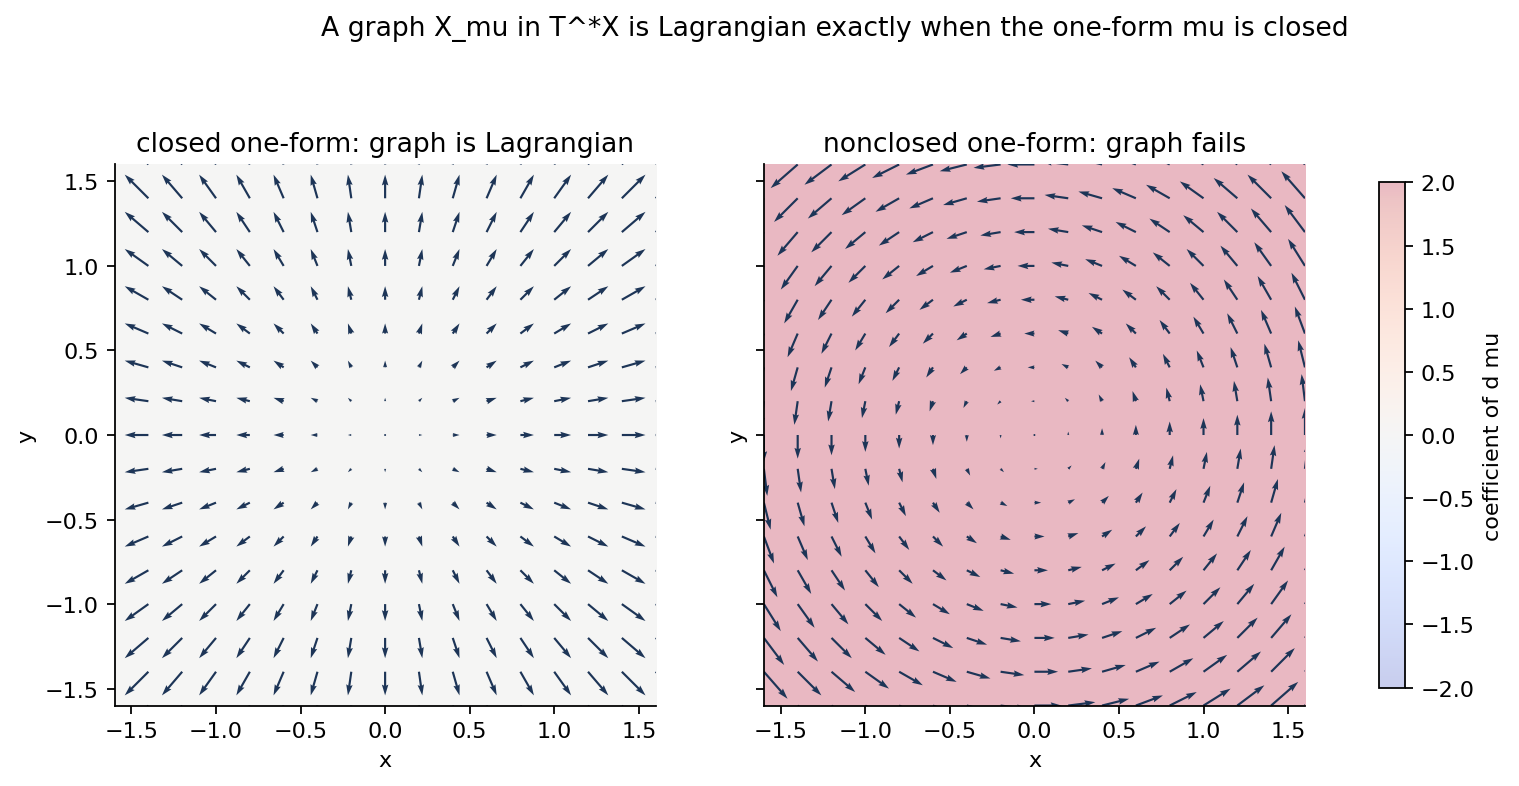

conormal bundle in adapted coordinates -> artifacts\lecture-03\figures\conormal-bundle-adapted-coordinates.png


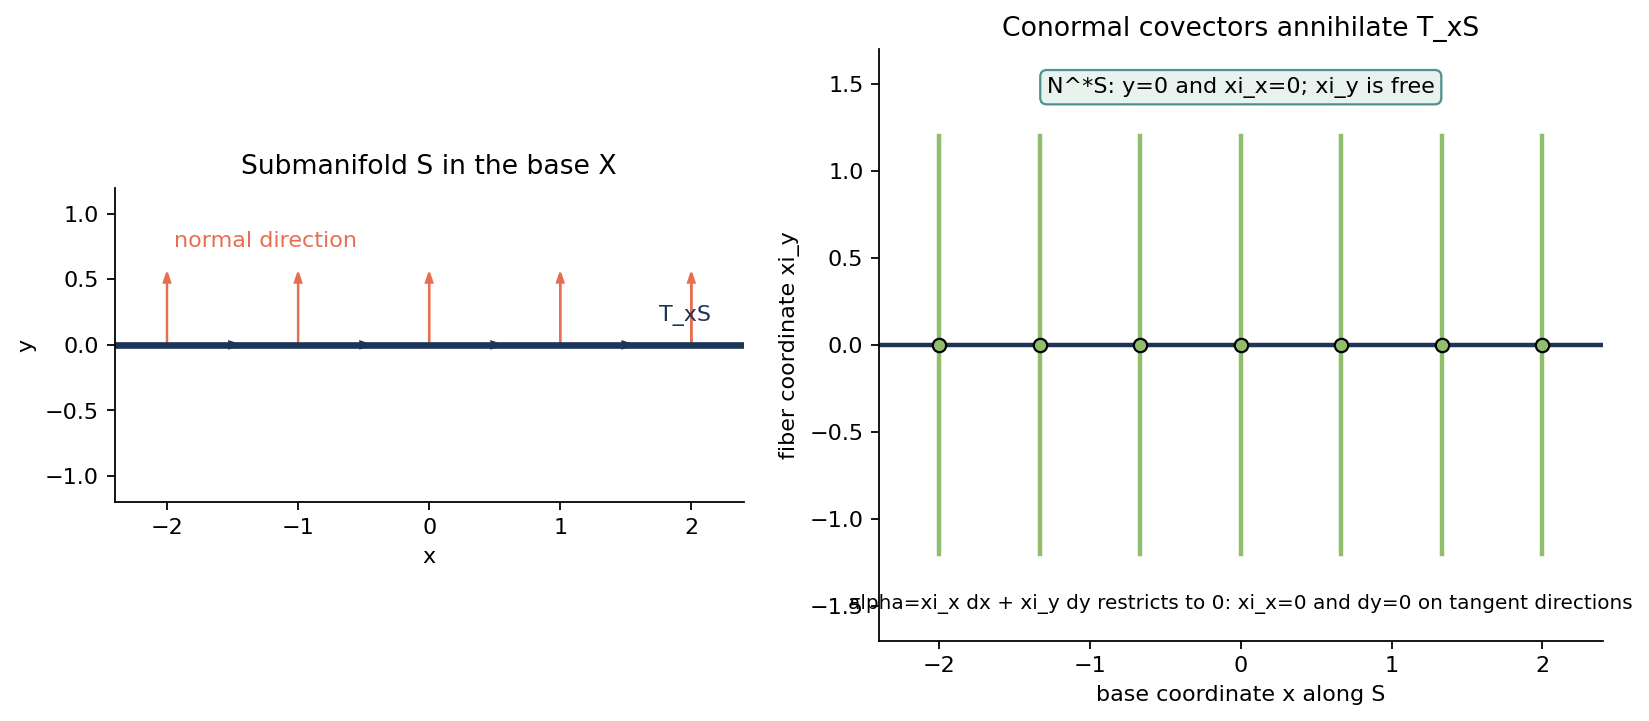

symplectomorphism graph criterion -> artifacts\lecture-03\figures\symplectomorphism-graph-twisted-product.png


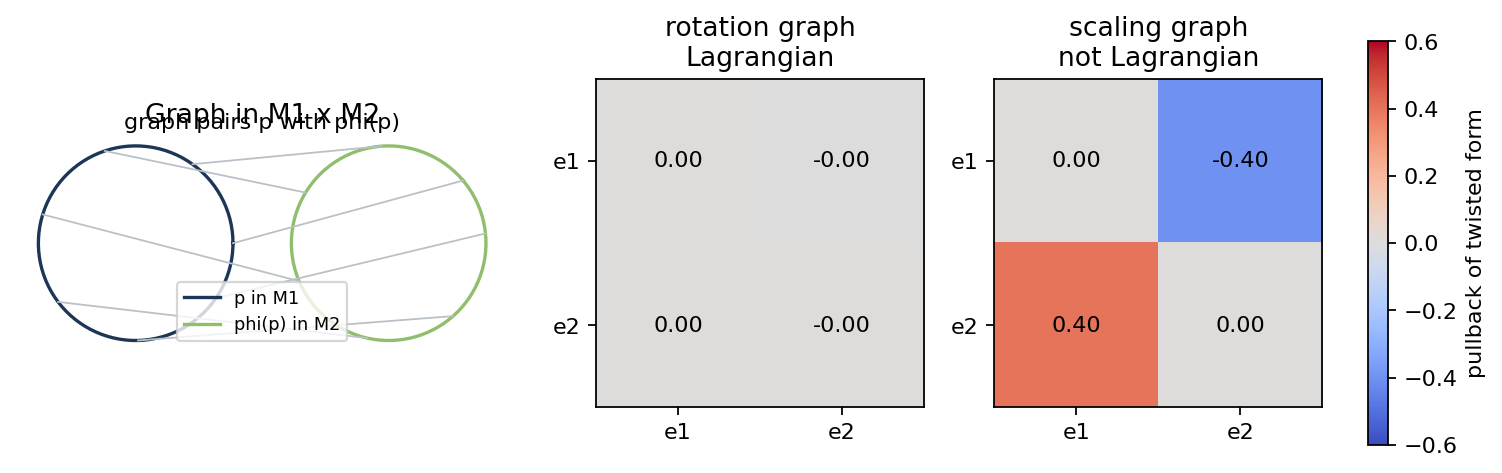

Liouville flow and exact fiber translations -> artifacts\lecture-03\figures\liouville-flow-and-exact-fiber-translation.png


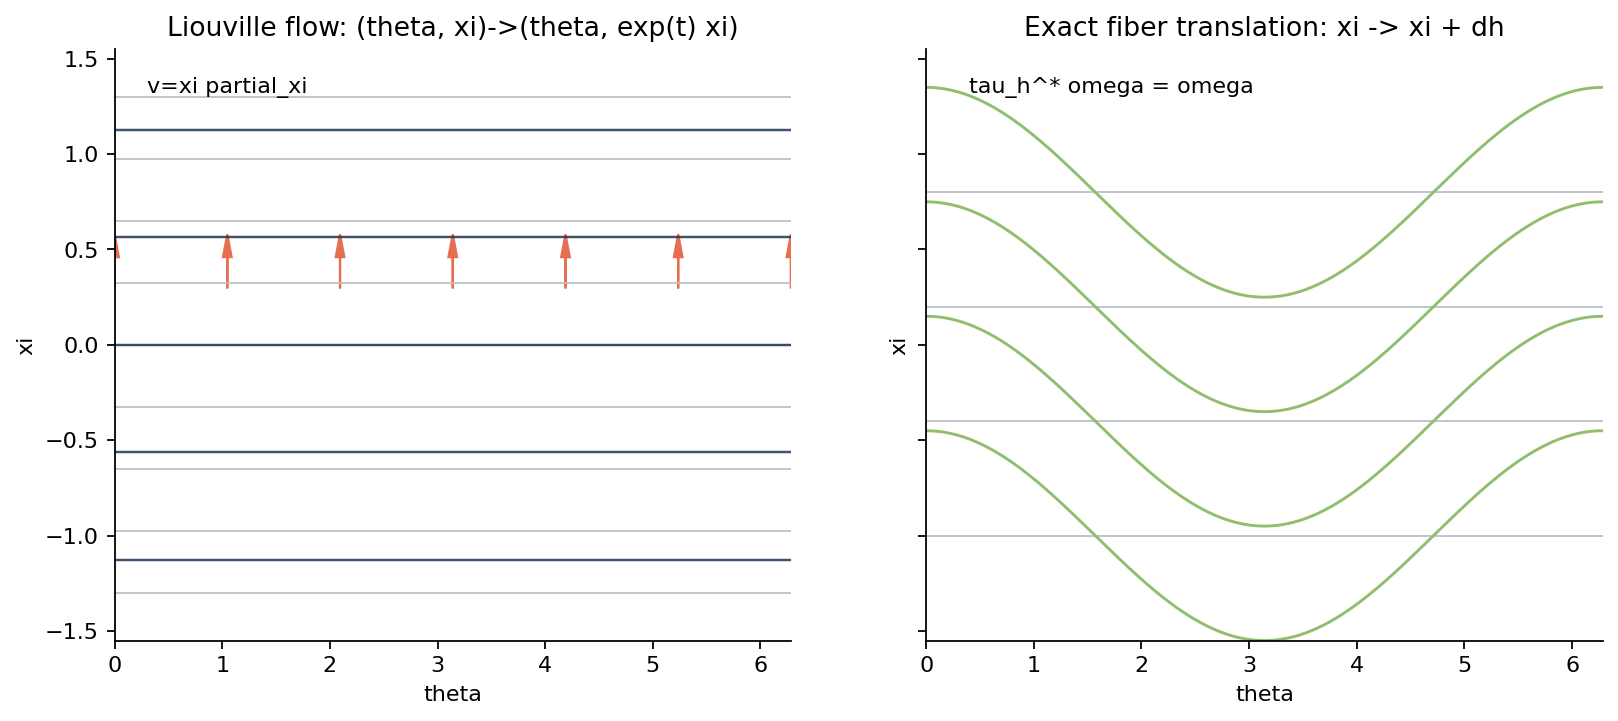

Lagrangian proof dependency route -> artifacts\lecture-03\figures\lagrangian-submanifolds-proof-route.png


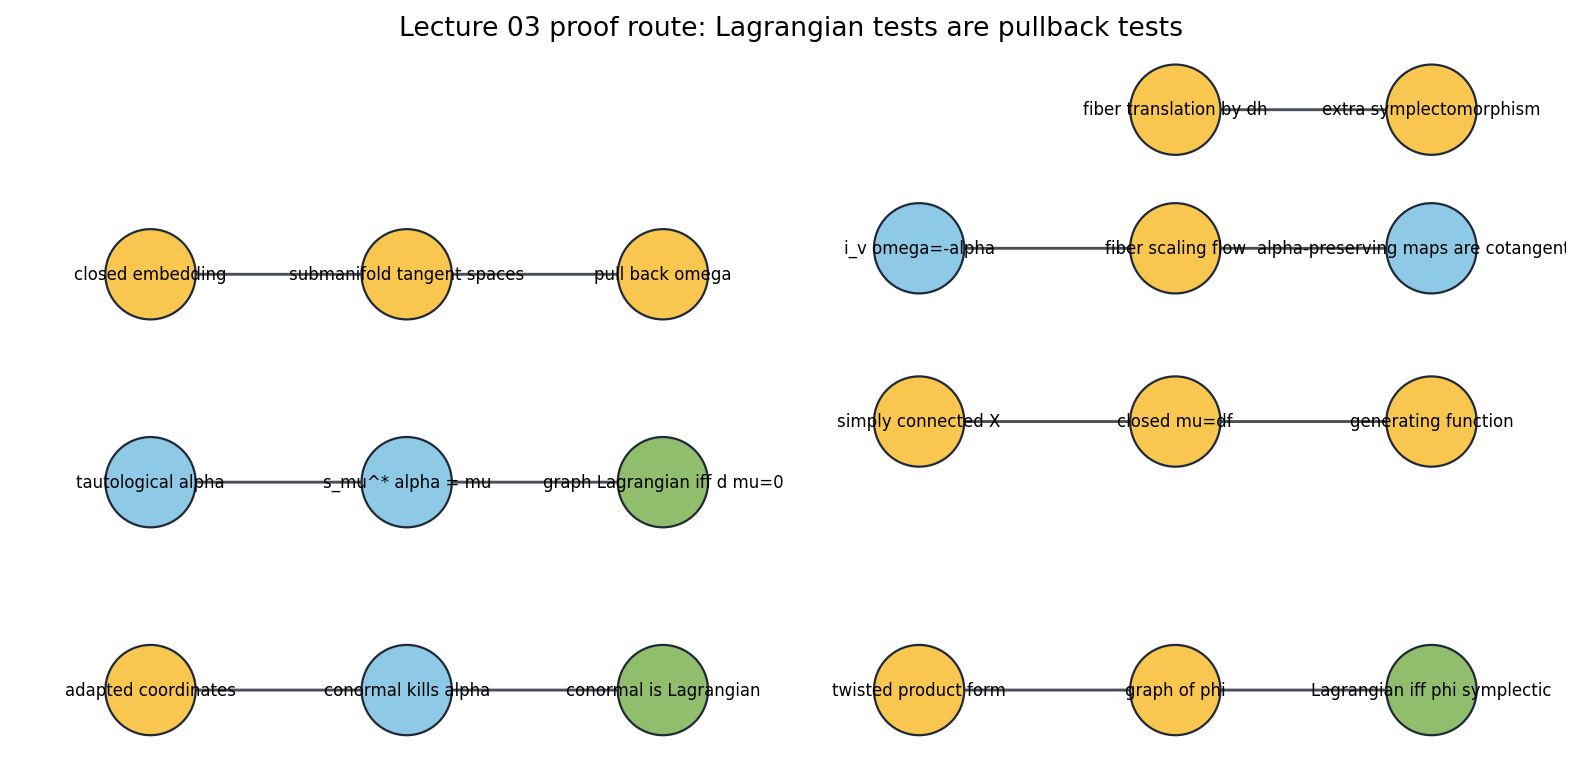

In [9]:
storyboard = read_json(ARTIFACT_ROOT / "checks" / "visual-storyboard.json")
for item in storyboard["visual_sequence"]:
    path = BOOK_ROOT / item["artifact"]
    print(f"{item['concept']} -> {path.relative_to(BOOK_ROOT)}")
    display_artifact(path, width=820)

## Takeaways

- The Lagrangian condition is a pullback condition: half the ambient dimension plus zero restricted two-form.
- The zero section is Lagrangian, and the graph of a one-form `mu` is Lagrangian exactly when `mu` is closed.
- On simply connected bases, closed one-forms are exact, so generating functions produce Lagrangian graphs by `df`.
- Conormal bundles are Lagrangian because the tautological one-form vanishes on them in adapted coordinates.
- A diffeomorphism is a symplectomorphism exactly when its graph is Lagrangian for the twisted product form.
- The homework Liouville field and exact fiber translations show how cotangent-bundle symplectomorphisms interact with `alpha`, fiber scaling, and the base fibration.

**Exploration prompt.** Replace the exact one-form `df` by `df + (-y dx + x dy)` in the graph test. Watch how the residual isolates the nonclosed part.